In [ ]:
pip install pandas numpy scikit-learn tensorflow matplotlib openpyxl

Dữ liệu đầu vào:
        Date  Price
0   1/3/2005  15770
1   1/4/2005  15771
2   1/5/2005  15783
3   1/6/2005  15782
4   1/7/2005  15785
5  1/10/2005  15770
6  1/11/2005  15770
7  1/12/2005  15765
8  1/13/2005  15772
9  1/14/2005  15770

✅ Bắt đầu huấn luyện mô hình...
Epoch 1/100
271/271 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0227 - val_loss: 5.9919e-04
Epoch 2/100
271/271 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0016 - val_loss: 0.0011
Epoch 3/100
271/271 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0011 - val_loss: 1.1453e-04
Epoch 4/100
271/271 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 7.1994e-04 - val_loss: 1.9768e-04
Epoch 5/100
271/271 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5.9181e-04 - val_loss: 2.2168e-04
Epoch 6/100
271/271 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5.9152e-04 - val_loss: 1.0099e-04
Epoch 7/100
271/271 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5.5779e-04 - val_loss: 6.3275e-05
Epoch 8/100
271/271 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5.8074e-04 - val_l

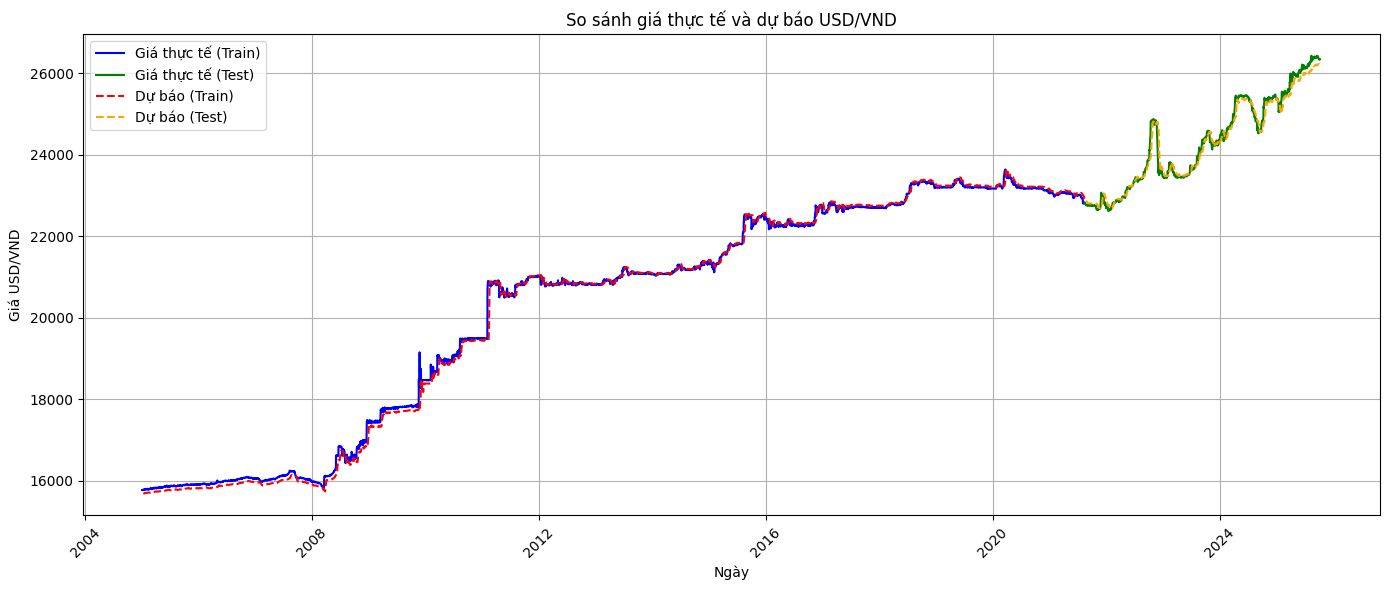

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step

📈 Dự báo 5 ngày tiếp theo:
2025-10-16: 26169.71 VND
2025-10-17: 26134.12 VND
2025-10-18: 26087.79 VND
2025-10-19: 26035.97 VND
2025-10-20: 25980.97 VND
Train MAE: 61.07
Test MAE: 74.27


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import warnings
warnings.filterwarnings('ignore')

# 1. Đọc dữ liệu (giả sử bạn lưu dữ liệu vào file 'usd_vnd.xlsx')
# Nếu bạn có dữ liệu trong clipboard hoặc muốn nhập trực tiếp, có thể thay bằng DataFrame
df = pd.read_csv('https://raw.githubusercontent.com/quangnhat1395/MLEF1/refs/heads/master/Data.csv')  # Thay tên file nếu cần

# Kiểm tra dữ liệu
print("Dữ liệu đầu vào:")
print(df.head(10))

# Chuyển cột Date sang kiểu datetime
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')

# Sắp xếp theo ngày (nếu chưa sắp xếp)
df = df.sort_values('Date').reset_index(drop=True)

# Lấy cột Price làm chuỗi thời gian
data = df['Price'].values.reshape(-1, 1)

# 2. Chuẩn hóa dữ liệu
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# 3. Tạo tập dữ liệu huấn luyện (sử dụng window size = 5)
def create_dataset(dataset, time_step=5):
    X, y = [], []
    for i in range(len(dataset) - time_step):
        X.append(dataset[i:(i + time_step), 0])
        y.append(dataset[i + time_step, 0])
    return np.array(X), np.array(y)

time_step = 5
X, y = create_dataset(scaled_data, time_step)

# Chia train/test (80% train, 20% test)
split_ratio = 0.8
split_index = int(len(X) * split_ratio)

X_train = X[:split_index]
y_train = y[:split_index]
X_test = X[split_index:]
y_test = y[split_index:]

# Reshape lại để phù hợp với LSTM: [samples, time steps, features]
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# 4. Xây dựng mô hình LSTM
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(time_step, 1)))
model.add(Dropout(0.2))
model.add(LSTM(50, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(25))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

# 5. Huấn luyện mô hình
print("\n✅ Bắt đầu huấn luyện mô hình...")
history = model.fit(X_train, y_train, batch_size=16, epochs=100, validation_data=(X_test, y_test), verbose=1)

# 6. Dự báo trên tập test
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# 7. Chuyển đổi lại về thang đo gốc
train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)
y_train_inv = scaler.inverse_transform(y_train.reshape(-1, 1))
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))

# 8. Đánh giá mô hình
train_rmse = np.sqrt(mean_squared_error(y_train_inv, train_predict))
test_rmse = np.sqrt(mean_squared_error(y_test_inv, test_predict))
print(f"\nTrain RMSE: {train_rmse:.2f}")
print(f"Test RMSE: {test_rmse:.2f}")

# 9. Vẽ biểu đồ so sánh
plt.figure(figsize=(14, 6))
plt.plot(df['Date'][:len(y_train)], y_train_inv, label='Giá thực tế (Train)', color='blue')
plt.plot(df['Date'][len(y_train):len(y_train)+len(y_test)], y_test_inv, label='Giá thực tế (Test)', color='green')
plt.plot(df['Date'][time_step:len(y_train)+time_step], train_predict, label='Dự báo (Train)', color='red', linestyle='--')
plt.plot(df['Date'][len(y_train)+time_step:len(y_train)+len(y_test)+time_step], test_predict, label='Dự báo (Test)', color='orange', linestyle='--')
plt.title('So sánh giá thực tế và dự báo USD/VND')
plt.xlabel('Ngày')
plt.ylabel('Giá USD/VND')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 10. Dự báo 5 ngày tiếp theo
last_sequence = scaled_data[-time_step:].reshape(1, time_step, 1)
forecast = []

for _ in range(5):  # Dự báo 5 ngày tới
    pred = model.predict(last_sequence)
    forecast.append(pred[0, 0])
    # Cập nhật sequence mới
    last_sequence = np.append(last_sequence[:, 1:, :], pred.reshape(1, 1, 1), axis=1)

# Chuyển đổi dự báo về giá trị gốc
forecast = scaler.inverse_transform(np.array(forecast).reshape(-1, 1))

# In kết quả dự báo
print("\n📈 Dự báo 5 ngày tiếp theo:")
future_dates = pd.date_range(start=df['Date'].iloc[-1] + pd.Timedelta(days=1), periods=5, freq='D')
for date, price in zip(future_dates, forecast.flatten()):
    print(f"{date.strftime('%Y-%m-%d')}: {price:.2f} VND")

from sklearn.metrics import mean_absolute_error

print(f"Train MAE: {mean_absolute_error(y_train_inv, train_predict):.2f}")
print(f"Test MAE: {mean_absolute_error(y_test_inv, test_predict):.2f}")